# Cross-Method Comparison

Loads saved results from all models and produces a unified comparison
table, side-by-side confusion matrices, and discussion points for the report.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from ser_utils import NUM_CLASSES, EMOTION_ENG_MAP

RESULTS_DIR = "results"
EMOTION_NAMES = [EMOTION_ENG_MAP[i] for i in range(NUM_CLASSES)]

## Load Results

In [3]:
results = {
    # ── Teammate baselines (leave blank — to be filled by teammate) ──────────
    "DCNN+DTPM+SVM": {
        "accuracy": None,
        "f1_macro": None,
        "params": "~57M + SVM",
        "cm": None,
        "group": "Teammate Baseline",
    },
    "CNN+BiLSTM": {
        "accuracy": None,
        "f1_macro": None,
        "params": "~62M",
        "cm": None,
        "group": "Teammate Baseline",
    },

    # ── Track 1: Transformer model for SER ───────────────────────────────────
    # (a) Original transformer
    "MelTransformer": {
        "accuracy": 0.5720,
        "f1_macro": 0.52,
        "params": "~430K",
        "cm": None,
        "group": "1a. Original Transformer",
    },
    # (b) Enhanced transformer
    "MelTransformerEnhanced": {
        "accuracy": 0.7607,
        "f1_macro": 0.75,
        "params": "~1.2M",
        "cm": None,
        "group": "1b. Enhanced Transformer",
    },

    # ── Track 2: Pretrained model finetuned on SER ───────────────────────────
    # (a) Baseline wav2vec2
    "Wav2Vec2-base": {
        "accuracy": 0.8542,
        "f1_macro": 0.85,
        "params": "~95M",
        "cm": None,
        "group": "2a. Pretrained Baseline",
    },
    # (b) Wav2Vec2 + attnstat (light improvement observed)
    "Wav2Vec2-base-attnstat": {
        "accuracy": 0.8579,
        "f1_macro": 0.8521,
        "params": "~95M",
        "cm": None,
        "group": "2b. Wav2Vec2+attnstat",
    },
    # (c) Ablation: other pretrained models + attnstat
    "WavLM-base-attnstat": {
        "accuracy": 0.8654,
        "f1_macro": 0.8533,
        "params": "~94M",
        "cm": None,
        "group": "2c. Ablation",
    },
    "Whisper-base": {
        "accuracy": 0.8280,
        "f1_macro": 0.8202,
        "params": "~74M",
        "cm": None,
        "group": "2c. Ablation",
    },
    "HuBERT-base-attnstat": {
        "accuracy": 0.8579,
        "f1_macro": 0.8544,
        "params": "~95M",
        "cm": None,
        "group": "2c. Ablation",
    },
}

for model_name in [k for k in results if results[k]["group"] not in ("Teammate Baseline",)]:
    report_path = os.path.join(RESULTS_DIR, f"report_{model_name}_loso.txt")
    if os.path.exists(report_path):
        with open(report_path) as f:
            content = f.read()
        print(f"\n{'=' * 50}")
        print(f"  {model_name}")
        print(f"{'=' * 50}")
        print(content)


  MelTransformer
Model: MelTransformer
Split: loso
Utterance-level accuracy: 57.20%

              precision    recall  f1-score   support

       Anger       0.63      0.89      0.74       127
     Boredom       0.51      0.54      0.53        81
        Fear       0.53      0.23      0.32        69
   Happiness       0.44      0.23      0.30        71
     Sadness       0.77      0.95      0.85        62
     Disgust       0.38      0.59      0.46        46
     Neutral       0.55      0.39      0.46        79

    accuracy                           0.57       535
   macro avg       0.55      0.55      0.52       535
weighted avg       0.56      0.57      0.54       535


  MelTransformerEnhanced
Model: MelTransformerEnhanced
Split: loso
Utterance-level accuracy: 76.07%

              precision    recall  f1-score   support

       Anger       0.89      0.84      0.87       127
     Boredom       0.76      0.58      0.66        81
        Fear       0.61      0.67      0.64        6

## Comparison Table

In [5]:
GROUP_ORDER = [
    "Teammate Baseline",
    "1a. Original Transformer",
    "1b. Enhanced Transformer",
    "2a. Pretrained Baseline",
    "2b. Wav2Vec2+attnstat",
    "2c. Ablation",
]

GROUP_LABELS = {
    "Teammate Baseline":      "── YZ baselines ──────────────────────────────────────────",
    "1a. Original Transformer": "── Track 1: Transformer for SER ────────────────────────────────",
    "1b. Enhanced Transformer":  None,
    "2a. Pretrained Baseline":   "── Track 2: Pretrained Finetuning ──────────────────────────────",
    "2b. Wav2Vec2+attnstat":     None,
    "2c. Ablation":              "  Ablation:",
}

def fmt_acc(x):
    return f"{x*100:.2f}%" if x is not None else "     —"

def fmt_f1(x):
    return f"{x:.4f}" if x is not None else "     —"

print(f"{'Model':<28} {'Accuracy':>10} {'F1-macro':>10} {'Params':>15}")
print("═" * 68)
last_group = None
for group in GROUP_ORDER:
    for name, r in results.items():
        if r.get("group") != group:
            continue
        if group != last_group:
            label = GROUP_LABELS.get(group)
            if label:
                print(f"\n{label}")
            last_group = group
        print(f"  {name:<26} {fmt_acc(r['accuracy']):>10} {fmt_f1(r['f1_macro']):>10} {r['params']:>15}")

Model                          Accuracy   F1-macro          Params
════════════════════════════════════════════════════════════════════

── YZ baselines ──────────────────────────────────────────
  DCNN+DTPM+SVM                       —          —      ~57M + SVM
  CNN+BiLSTM                          —          —            ~62M

── Track 1: Transformer for SER ────────────────────────────────
  MelTransformer                 57.20%     0.5200           ~430K
  MelTransformerEnhanced         76.07%     0.7500           ~1.2M

── Track 2: Pretrained Finetuning ──────────────────────────────
  Wav2Vec2-base                  85.42%     0.8500            ~95M
  Wav2Vec2-base-attnstat         85.79%     0.8521            ~95M

  Ablation:
  WavLM-base-attnstat            86.54%     0.8533            ~94M
  Whisper-base                   82.80%     0.8202            ~74M
  HuBERT-base-attnstat           85.79%     0.8544            ~95M


## Analysis

Model                                    Accuracy   Macro-F1 Source
------------------------------------------------------------------------------------------
Pretrained-Ensemble-top4                   90.65%     0.9018 results\report_Pretrained-Ensemble-top4_loso.txt
Pretrained-Ensemble-top3                   89.72%     0.8916 results\report_Pretrained-Ensemble-top3_loso.txt
Pretrained-Ensemble-top2                   88.04%     0.8789 results\report_Pretrained-Ensemble-top2_loso.txt
Wav2Vec2-base-attnstat                     86.54%     0.8533 results\report_Wav2Vec2-base-attnstat_loso.txt
WavLM-base-attnstat                        86.36%     0.8614 results\report_WavLM-base-attnstat_loso.txt
HuBERT-base-attnstat                       85.79%     0.8544 results\report_HuBERT-base-attnstat_loso.txt
Wav2Vec2-base                              85.42%     0.8500 results\report_Wav2Vec2-base_loso.txt
Whisper-base                               82.80%     0.8202 results\report_Whisper-base_loso

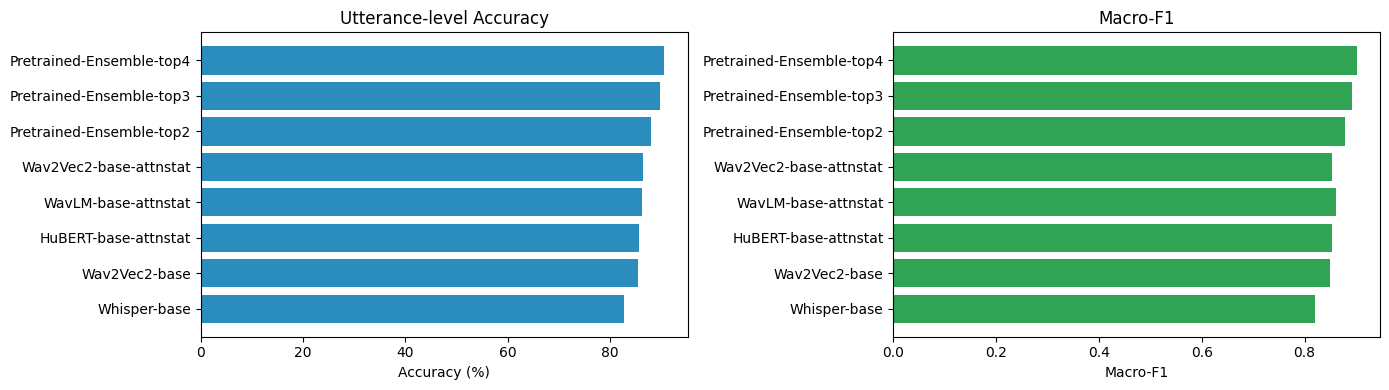

Saved plot: results\comparison_accuracy_first.png


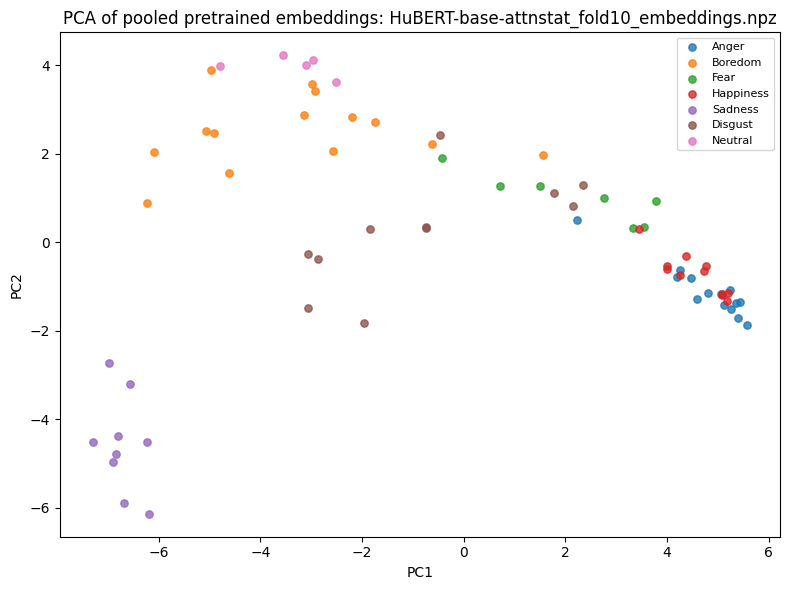

Saved PCA plot: results\best_pretrained_embedding_pca.png


In [ ]:
import csv
import re
from pathlib import Path
from sklearn.decomposition import PCA


COMPARISON_RESULTS_DIR = Path(RESULTS_DIR)
TEAMMATE_RESULT_FILES = {
    "DCNN+DTPM+SVM": "SC4001-Neural-Network-Project/SER_DCNN_DTPM/results/processed_emodb_norm_loso_aug/classification_report_processed_emodb_speaker_norm_loso_aug.txt",
    "CNN+BiLSTM": "SC4001-Neural-Network-Project/SER_DCNN_DTPM/results/processed_emodb_comb_norm_loso/classification_report_lstm_processed_emodb_comb_norm_loso.txt",
}


def parse_accuracy_from_text(text: str):
    m = re.search(r"(?:Utterance-level accuracy|Final SVM utterance-level accuracy \(loso\)|LOSO combined utterance-level accuracy):\s*([0-9.]+)%", text)
    return float(m.group(1)) / 100 if m else None


def parse_macro_f1_from_text(text: str):
    m = re.search(r"macro avg\s+([0-9.]+)\s+([0-9.]+)\s+([0-9.]+)", text)
    if m:
        return float(m.group(3))
    m = re.search(r"Macro-F1:\s*([0-9.]+)", text)
    return float(m.group(1)) if m else None


def load_report_metric(path):
    if not os.path.exists(path):
        return None
    text = Path(path).read_text(encoding="utf-8", errors="ignore")
    return {
        "accuracy": parse_accuracy_from_text(text),
        "f1_macro": parse_macro_f1_from_text(text),
        "path": path,
    }


refreshed_results = {}
for name, path in TEAMMATE_RESULT_FILES.items():
    metric = load_report_metric(path)
    if metric:
        refreshed_results[name] = {**metric, "params": "see baseline section"}

for report_path in sorted(COMPARISON_RESULTS_DIR.glob("report_*_loso.txt")):
    text = report_path.read_text(encoding="utf-8", errors="ignore")
    first_line = next((line for line in text.splitlines() if line.startswith("Model:")), None)
    model_name = first_line.split(":", 1)[1].strip() if first_line else report_path.stem.replace("report_", "").replace("_loso", "")
    metric = load_report_metric(str(report_path))
    if metric:
        refreshed_results[model_name] = {**metric, "params": "varies"}

summary_csv = COMPARISON_RESULTS_DIR / "pretrained_loso_summary.csv"
if summary_csv.exists():
    with summary_csv.open(newline="", encoding="utf-8") as f:
        for row in csv.DictReader(f):
            try:
                refreshed_results[row["short_name"]] = {
                    "accuracy": float(row["accuracy"]),
                    "f1_macro": float(row["macro_f1"]),
                    "params": "pretrained",
                    "path": row.get("report_path", ""),
                }
            except (KeyError, ValueError):
                continue

sorted_results = sorted(
    refreshed_results.items(),
    key=lambda item: (item[1].get("accuracy") or -1, item[1].get("f1_macro") or -1),
    reverse=True,
)

print(f"{'Model':<38} {'Accuracy':>10} {'Macro-F1':>10} {'Source':<}")
print("-" * 90)
for name, r in sorted_results:
    acc = r.get("accuracy")
    f1 = r.get("f1_macro")
    print(f"{name:<38} {acc * 100:>9.2f}% {f1:>10.4f} {r.get('path', '')}")

table_path = COMPARISON_RESULTS_DIR / "comparison_accuracy_first.csv"
with table_path.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["model", "accuracy", "macro_f1", "source"])
    writer.writeheader()
    for name, r in sorted_results:
        writer.writerow({"model": name, "accuracy": r.get("accuracy"), "macro_f1": r.get("f1_macro"), "source": r.get("path", "")})
print(f"Saved refreshed comparison table: {table_path}")

if sorted_results:
    top = sorted_results[: min(8, len(sorted_results))]
    names = [x[0] for x in top][::-1]
    accs = [x[1]["accuracy"] * 100 for x in top][::-1]
    f1s = [x[1]["f1_macro"] for x in top][::-1]
    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, 0.45 * len(names))))
    axes[0].barh(names, accs, color="#2b8cbe")
    axes[0].set_xlabel("Accuracy (%)")
    axes[0].set_title("Utterance-level Accuracy")
    axes[1].barh(names, f1s, color="#31a354")
    axes[1].set_xlabel("Macro-F1")
    axes[1].set_title("Macro-F1")
    fig.tight_layout()
    plot_path = COMPARISON_RESULTS_DIR / "comparison_accuracy_first.png"
    fig.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved plot: {plot_path}")


def plot_best_embedding_pca():
    candidates = sorted(COMPARISON_RESULTS_DIR.glob("*_fold*_embeddings.npz"))
    if not candidates:
        print("No saved embedding files found yet; run a pretrained experiment with embedding export first.")
        return
    latest = max(candidates, key=lambda p: p.stat().st_mtime)
    data = np.load(latest, allow_pickle=True)
    X = data["embeddings"]
    y = data["labels"]
    if len(X) < 3:
        print("Not enough embeddings for PCA.")
        return
    X2 = PCA(n_components=2, random_state=42).fit_transform(X)
    fig, ax = plt.subplots(figsize=(8, 6))
    for label_idx, emotion_name in enumerate(EMOTION_NAMES):
        mask = y == label_idx
        if mask.any():
            ax.scatter(X2[mask, 0], X2[mask, 1], label=emotion_name, s=28, alpha=0.8)
    ax.set_title(f"PCA of pooled pretrained embeddings: {latest.name}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()
    out = COMPARISON_RESULTS_DIR / "best_pretrained_embedding_pca.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved PCA plot: {out}")


plot_best_embedding_pca()


## Final Comparison Table

In [2]:

# FINAL_COMPARISON_TABLE
# Structured by category. Teammate baselines left blank intentionally.

import csv
import re
from pathlib import Path

FINAL_RESULTS_DIR = Path(RESULTS_DIR)

CATEGORIES = [
    {
        "label": "Teammate Baselines (to be filled)",
        "models": [
            {"model": "DCNN+DTPM+SVM",                    "accuracy": None, "macro_f1": None, "notes": "To fill"},
            {"model": "CNN+BiLSTM",                        "accuracy": None, "macro_f1": None, "notes": "To fill"},
        ],
    },
    {
        "label": "Track 1 — Transformer for SER",
        "models": [
            {"model": "MelTransformer (original)",         "report": "report_MelTransformer_loso.txt"},
            {"model": "MelTransformerEnhanced (enhanced)", "report": "report_MelTransformerEnhanced_loso.txt"},
        ],
    },
    {
        "label": "Track 2 — Pretrained Finetuning",
        "models": [
            {"model": "Wav2Vec2-base (baseline)",          "report": "report_Wav2Vec2-base_loso.txt"},
            {"model": "Wav2Vec2-base-attnstat",            "report": "report_Wav2Vec2-base-attnstat_loso.txt"},
        ],
    },
    {
        "label": "Track 2 — Ablation: other architectures",
        "models": [
            {"model": "WavLM-base-attnstat",               "report": "report_WavLM-base-attnstat_loso.txt"},
            {"model": "Whisper-base",                      "report": "report_Whisper-base_loso.txt"},
            {"model": "HuBERT-base-attnstat",              "report": "report_HuBERT-base-attnstat_loso.txt"},
        ],
    },
]


def parse_report(path):
    text = Path(path).read_text(encoding="utf-8", errors="ignore")
    acc_m = re.search(r"Utterance-level accuracy:\s*([0-9.]+)%", text)
    f1_m  = re.search(r"Macro-F1:\s*([0-9.]+)", text)
    f1_m2 = re.search(r"macro avg\s+[0-9.]+\s+[0-9.]+\s+([0-9.]+)", text)
    return {
        "accuracy": float(acc_m.group(1)) / 100 if acc_m else None,
        "macro_f1": float(f1_m.group(1)) if f1_m else (float(f1_m2.group(1)) if f1_m2 else None),
        "notes": str(path),
    }


def fmt_p(x):
    return "[to fill]" if x is None else f"{x * 100:.2f}%"

def fmt_f(x):
    return "[to fill]" if x is None else f"{x:.4f}"


all_rows = []
print(f"{'Model':<48} {'Accuracy':>10} {'Macro-F1':>10}  Notes")
print("=" * 100)

for cat in CATEGORIES:
    print(f"\n  {cat['label']}")
    print("  " + "-" * 90)
    for entry in cat["models"]:
        row = {"model": entry["model"], "accuracy": entry.get("accuracy"), "macro_f1": entry.get("macro_f1"), "notes": entry.get("notes", "")}
        if "report" in entry:
            rpath = FINAL_RESULTS_DIR / entry["report"]
            if rpath.exists():
                parsed = parse_report(rpath)
                row.update(parsed)
        print(f"    {row['model']:<46} {fmt_p(row['accuracy']):>10} {fmt_f(row['macro_f1']):>10}  {row['notes']}")
        all_rows.append(row)

out_path = FINAL_RESULTS_DIR / "final_comparison_structured.csv"
with out_path.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["model", "accuracy", "macro_f1", "notes"])
    writer.writeheader()
    writer.writerows(all_rows)
print(f"\nSaved: {out_path}")


Model                                              Accuracy   Macro-F1  Notes

  Teammate Baselines (to be filled)
  ------------------------------------------------------------------------------------------
    DCNN+DTPM+SVM                                   [to fill]  [to fill]  To fill
    CNN+BiLSTM                                      [to fill]  [to fill]  To fill

  Track 1 — Transformer for SER
  ------------------------------------------------------------------------------------------
    MelTransformer (original)                          57.20%     0.5200  results\report_MelTransformer_loso.txt
    MelTransformerEnhanced (enhanced)                  76.07%     0.7500  results\report_MelTransformerEnhanced_loso.txt

  Track 2 — Pretrained Finetuning
  ------------------------------------------------------------------------------------------
    Wav2Vec2-base (baseline)                           85.42%     0.8500  results\report_Wav2Vec2-base_loso.txt
    Wav2Vec2-base-attnstat  